In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

file_path = "../data/raw/WHR26_Data_Figure_2.1.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (2116, 13)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [2]:
# Dataset inspection

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape: (2116, 13)

Column Names:
['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']

Data Types:
Year                                            int64
Rank                                            int64
Country name                                      str
Life evaluation (3-year average)              float64
Lower whisker                                 float64
Upper whisker                                 float64
Explained by: Log GDP per capita              float64
Explained by: Social support                  float64
Explained by: Healthy life expectancy         float64
Explained by: Freedom to make life choices    float64
Explained by: Generosity                      float64


,Year,Rank,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [3]:
# Detailed missing-value analysis

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Values"] > 0].sort_values(
    "Missing Values", ascending=False
)

print("Missing Values by Column:")
display(missing)

Missing Values by Column:


,Missing Values,Missing %
Dystopia + residual,1103,52.13
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94
Explained by: Perceptions of corruption,1098,51.89
Explained by: Log GDP per capita,1097,51.84
Explained by: Generosity,1097,51.84
Explained by: Social support,1097,51.84
Lower whisker,1094,51.70
Upper whisker,1094,51.70


In [4]:
# Check missing values by year

missing_by_year = df.groupby("Year").apply(
    lambda x: x.isnull().sum().sum()
)

print("Total missing values by year:")
display(missing_by_year)

Total missing values by year:


Year
2011    1404
2012    1404
2014    1422
2015    1413
2016    1395
2017    1404
2018    1404
2019       0
2020       0
2021       0
2022       2
2023      21
2024       6
2025       4
dtype: int64

In [5]:
# Check missing percentage for each important column by year

columns_to_check = [
    "Life evaluation (3-year average)",
    "Lower whisker",
    "Upper whisker",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]

missing_year_table = (
    df.groupby("Year")[columns_to_check]
      .apply(lambda x: x.isnull().mean() * 100)
      .round(2)
)

display(missing_year_table)

,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
Year,,,,,,,,,,
2011,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2012,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2014,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2015,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2016,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2017,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2018,0.0,100.0,100.0,100.0,100.0,100.00,100.00,100.0,100.00,100.00
2019,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00
2020,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00


In [6]:
# Create a clean dataset for analysis

df_clean = df.copy()

# Remove rows only if the main life-evaluation value is missing
df_clean = df_clean.dropna(
    subset=["Life evaluation (3-year average)"]
)

print("Original dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
display(
    df_clean.isnull().sum()
)

Original dataset shape: (2116, 13)
Clean dataset shape: (2116, 13)

Remaining missing values:


Year                                             0
Rank                                             0
Country name                                     0
Life evaluation (3-year average)                 0
Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64

In [7]:
# Dataset for factor and correlation analysis

factor_columns = [
    "Life evaluation (3-year average)",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

df_factors = df_clean[factor_columns].dropna()

print("Factor analysis dataset shape:", df_factors.shape)

display(df_factors.head())

Factor analysis dataset shape: (1013, 7)


,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
0,7.764,1.915,1.638,0.939,1.105,0.093,0.491
1,7.540,1.971,1.720,0.996,1.105,0.187,0.187
2,7.539,1.986,1.633,0.930,1.081,0.125,0.474
3,7.439,1.697,1.483,0.739,1.101,0.059,0.122
4,7.255,1.950,1.570,1.027,1.070,0.149,0.447


In [8]:
# Descriptive statistics for happiness and its explanatory factors

print("Descriptive Statistics:")
display(df_factors.describe().T)

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Life evaluation (3-year average),1013.0,5.552652,1.127344,1.364,4.7293,5.714,6.387400,7.842000
Explained by: Log GDP per capita,1013.0,1.266128,0.464868,0.000,0.9440,1.306,1.636000,2.209000
Explained by: Social support,1013.0,1.094809,0.357753,0.000,0.8650,1.135,1.378644,1.840000
Explained by: Healthy life expectancy,1013.0,0.553158,0.230177,0.000,0.3890,0.560,0.712000,1.238000
Explained by: Freedom to make life choices,1013.0,0.609201,0.212121,0.000,0.4710,0.602,0.735000,1.147000
Explained by: Generosity,1013.0,0.147717,0.084417,0.000,0.0890,0.134,0.196000,0.569814
Explained by: Perceptions of corruption,1013.0,0.144717,0.118731,0.000,0.0630,0.113,0.181000,0.587000


In [9]:
# Average value of each happiness factor

factor_means = df_factors.mean().sort_values(ascending=False)

print("Average Factor Values:")
display(factor_means)

Average Factor Values:


Life evaluation (3-year average)              5.552652
Explained by: Log GDP per capita              1.266128
Explained by: Social support                  1.094809
Explained by: Freedom to make life choices    0.609201
Explained by: Healthy life expectancy         0.553158
Explained by: Generosity                      0.147717
Explained by: Perceptions of corruption       0.144717
dtype: float64

In [10]:
# Correlation analysis

correlation = df_factors.corr()

print("Correlation Matrix:")
display(correlation.round(2))

Correlation Matrix:


,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
Life evaluation (3-year average),1.00,0.68,0.71,0.66,0.49,0.03,0.43
Explained by: Log GDP per capita,0.68,1.00,0.63,0.54,0.49,-0.25,0.37
Explained by: Social support,0.71,0.63,1.00,0.53,0.50,-0.10,0.20
Explained by: Healthy life expectancy,0.66,0.54,0.53,1.00,0.29,-0.03,0.35
Explained by: Freedom to make life choices,0.49,0.49,0.50,0.29,1.00,-0.08,0.28
Explained by: Generosity,0.03,-0.25,-0.10,-0.03,-0.08,1.00,0.14
Explained by: Perceptions of corruption,0.43,0.37,0.20,0.35,0.28,0.14,1.00


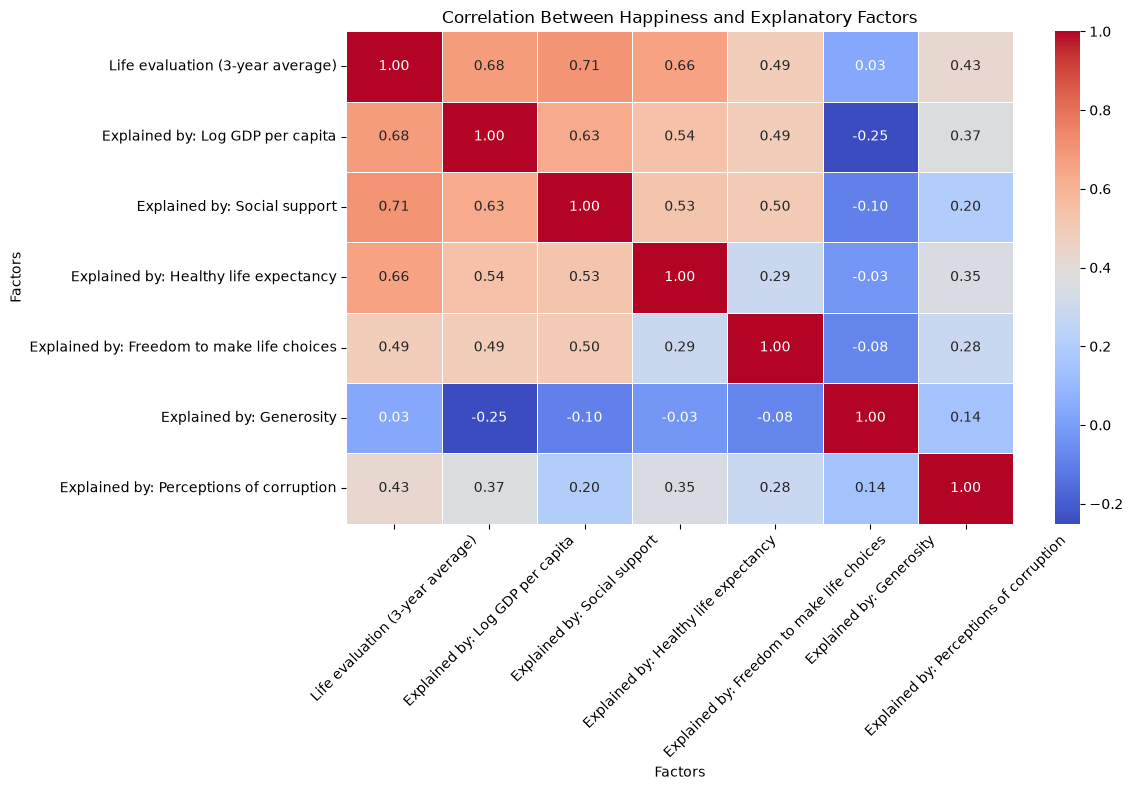

In [11]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Happiness and Explanatory Factors")

plt.xticks(rotation=45)

plt.xlabel("Factors")
plt.ylabel("Factors")

plt.tight_layout()
plt.show()

In [12]:
# Top 10 happiest countries

top_10 = (
    df_clean[["Year", "Rank", "Country name", "Life evaluation (3-year average)"]]
    .sort_values("Life evaluation (3-year average)", ascending=False)
    .head(10)
)

print("Top 10 Countries by Life Evaluation:")
display(top_10)

Top 10 Countries by Life Evaluation:


,Year,Rank,Country name,Life evaluation (3-year average)
1960,2011,1,Denmark,7.8560
720,2020,1,Finland,7.8420
574,2021,1,Finland,7.8210
869,2019,1,Finland,7.8087
437,2022,1,Finland,7.8040
1022,2018,1,Finland,7.7690
0,2025,1,Finland,7.7640
294,2023,1,Finland,7.7410
147,2024,1,Finland,7.7360
1804,2012,1,Denmark,7.6930


In [13]:
# Bottom 10 countries by life evaluation

bottom_10 = (
    df_clean[["Year", "Rank", "Country name", "Life evaluation (3-year average)"]].sort_values("Life evaluation (3-year average)", ascending=True).head(100)
)

print("Bottom 10 Countries by Life Evaluation:")
display(bottom_10)

Bottom 10 Countries by Life Evaluation:


,Year,Rank,Country name,Life evaluation (3-year average)
293,2024,147,Afghanistan,1.3640
146,2025,147,Afghanistan,1.4460
436,2023,143,Afghanistan,1.7210
573,2022,137,Afghanistan,1.8590
572,2022,136,Lebanon,2.3920
...,...,...,...,...
1012,2019,144,India,3.5733
713,2021,140,Sierra Leone,3.5740
1798,2014,153,Afghanistan,3.5750
1325,2017,148,Haiti,3.5820


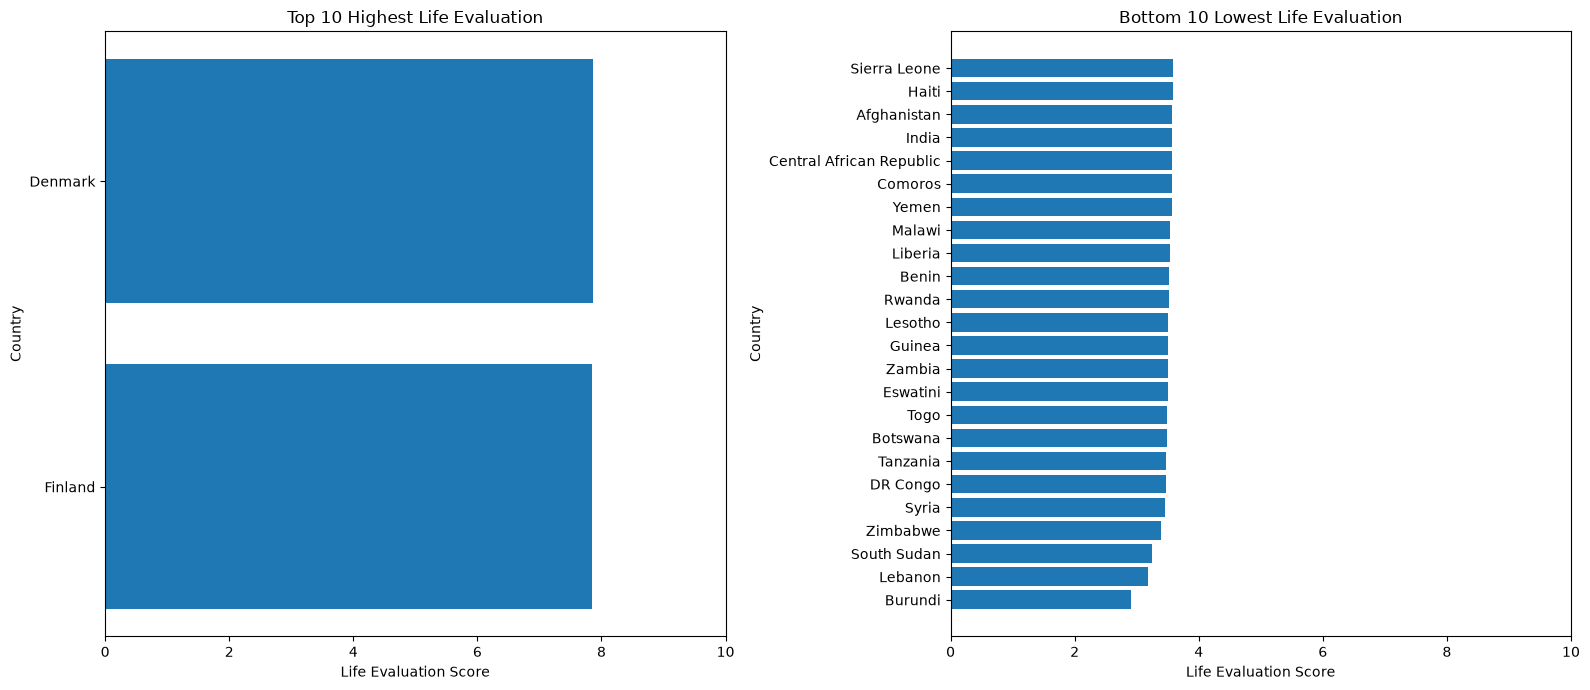

In [14]:
# Top 10 vs Bottom 10 countries

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10
top_plot = top_10.sort_values("Life evaluation (3-year average)")

axes[0].barh(
    top_plot["Country name"],
    top_plot["Life evaluation (3-year average)"]
)

axes[0].set_title("Top 10 Highest Life Evaluation")
axes[0].set_xlabel("Life Evaluation Score")
axes[0].set_ylabel("Country")
axes[0].invert_yaxis()  # Invert y-axis to have the highest score on top
axes[0].set_xlim(0, 10)  # Set x-axis limit for better comparison


# Bottom 10
bottom_plot = bottom_10.sort_values("Life evaluation (3-year average)", ascending=False)

axes[1].barh(
    bottom_plot["Country name"],
    bottom_plot["Life evaluation (3-year average)"]
)

axes[1].set_title("Bottom 10 Lowest Life Evaluation")
axes[1].set_xlabel("Life Evaluation Score")
axes[1].set_ylabel("Country")
axes[1].invert_yaxis()  # Invert y-axis to have the lowest score on top
axes[1].set_xlim(0, 10)  # Set x-axis limit for better comparison

plt.tight_layout()
plt.show()

In [15]:
# Create a country-level dataset using the latest available year

latest_country = (
    df_clean
    .sort_values("Year")
    .drop_duplicates(subset="Country name", keep="last")
)

print("Country-level dataset shape:", latest_country.shape)
display(
    latest_country[["Year", "Rank", "Country name", "Life evaluation (3-year average)"]].head(10)
)

Country-level dataset shape: (168, 13)


,Year,Rank,Country name,Life evaluation (3-year average)
2028,2011,69,Cuba,5.418
2004,2011,45,Guyana,5.993
1771,2014,126,Djibouti,4.369
1585,2015,97,Somaliland Region,5.057
1528,2015,40,Suriname,6.269
1503,2015,15,Puerto Rico,7.039
1319,2017,142,Angola,3.795
1314,2017,137,Sudan,4.139
1170,2018,149,Syria,3.462
1050,2018,29,Qatar,6.374


In [16]:
# Top 10 and Bottom 10 countries using latest available data

top_countries = (
    latest_country[
        ["Year", "Rank", "Country name", "Life evaluation (3-year average)"]
    ].sort_values("Life evaluation (3-year average)", ascending=False).head(10)
)

bottom_countries = (
    latest_country[
        ["Year", "Rank", "Country name", "Life evaluation (3-year average)"]
    ].sort_values("Life evaluation (3-year average)", ascending=True).head(10)
)

print("TOP 10 HAPPIEST COUNTRIES")
display(top_countries)

print("BOTTOM 10 LEAST HAPPY COUNTRIES")
display(bottom_countries)

TOP 10 HAPPIEST COUNTRIES


,Year,Rank,Country name,Life evaluation (3-year average)
0,2025,1,Finland,7.764
1,2025,2,Iceland,7.540
2,2025,3,Denmark,7.539
3,2025,4,Costa Rica,7.439
4,2025,5,Sweden,7.255
5,2025,6,Norway,7.242
6,2025,7,Netherlands,7.223
7,2025,8,Israel,7.187
8,2025,9,Luxembourg,7.063
1503,2015,15,Puerto Rico,7.039


BOTTOM 10 LEAST HAPPY COUNTRIES


,Year,Rank,Country name,Life evaluation (3-year average)
146,2025,147,Afghanistan,1.4460
1020,2019,152,South Sudan,2.8166
145,2025,146,Sierra Leone,3.2510
716,2021,143,Rwanda,3.2680
144,2025,145,Malawi,3.2840
143,2025,144,Zimbabwe,3.3460
1170,2018,149,Syria,3.4620
142,2025,143,Botswana,3.4640
1017,2019,149,Central African Republic,3.4759
141,2025,142,Yemen,3.5320


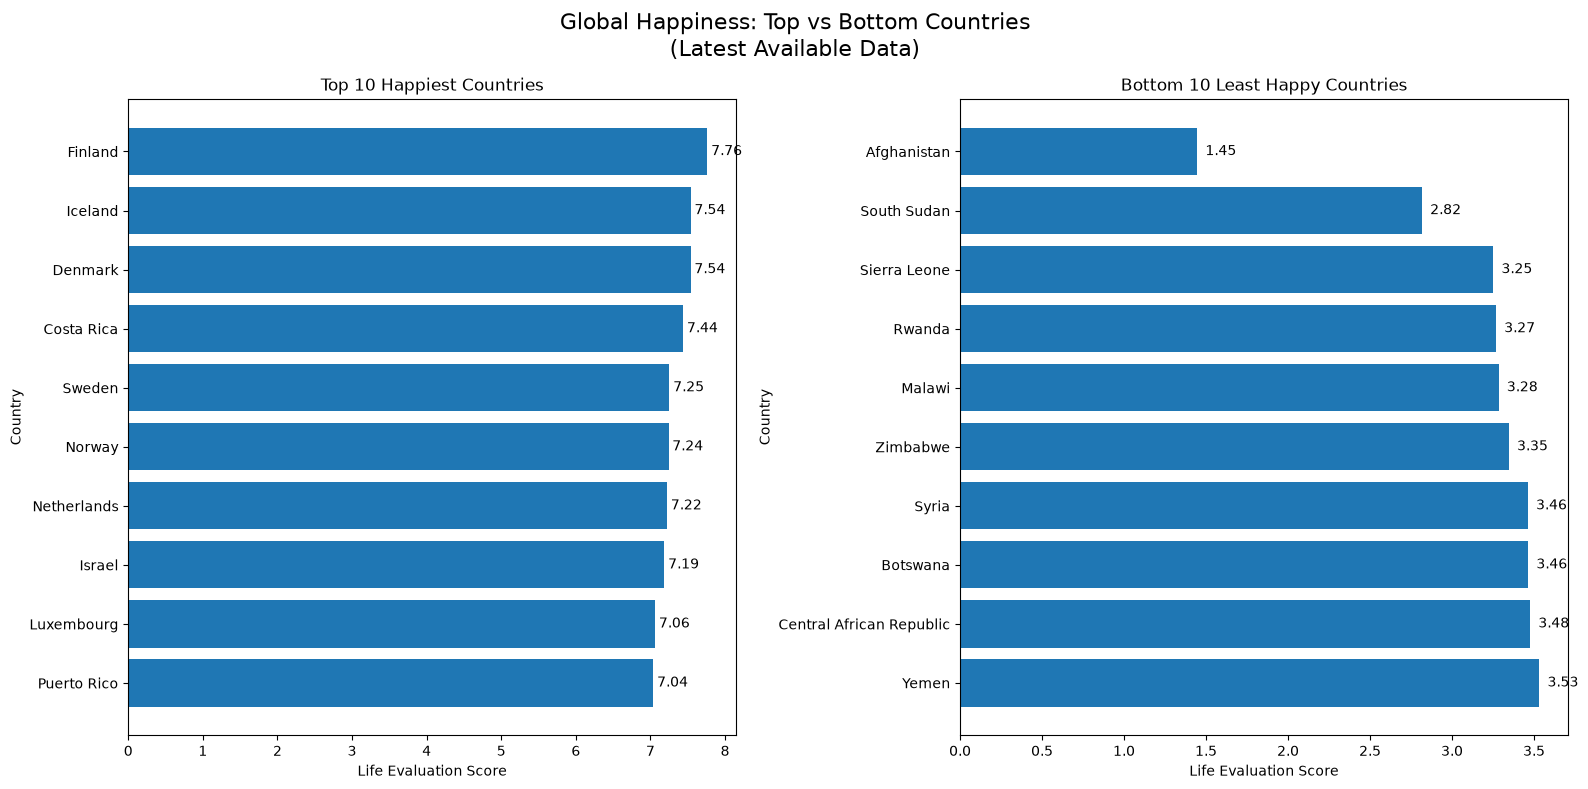

In [17]:
# Professional Top 10 vs Bottom 10 comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 10 Happiest Countries


top_plot = top_countries.sort_values(
    "Life evaluation (3-year average)"
)

bars1 = axes[0].barh(
    top_plot["Country name"],
    top_plot["Life evaluation (3-year average)"]
)

axes[0].set_title("Top 10 Happiest Countries")
axes[0].set_xlabel("Life Evaluation Score")
axes[0].set_ylabel("Country")

for bar in bars1:
    value = bar.get_width()
    axes[0].text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )


# Bottom 10 Least Happy

bottom_plot = bottom_countries.sort_values(
    "Life evaluation (3-year average)",
    ascending=False
)

bars2 = axes[1].barh(
    bottom_plot["Country name"],
    bottom_plot["Life evaluation (3-year average)"]
)

axes[1].set_title("Bottom 10 Least Happy Countries")
axes[1].set_xlabel("Life Evaluation Score")
axes[1].set_ylabel("Country")

for bar in bars2:
    value = bar.get_width()
    axes[1].text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )


plt.suptitle(
    "Global Happiness: Top vs Bottom Countries\n(Latest Available Data)",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [18]:


# Year-wise average happiness trend

yearly_happiness = (
    df_clean
    .groupby("Year")["Life evaluation (3-year average)"]
    .mean()
    .reset_index()
)

print("Year-wise Average Happiness:")
display(yearly_happiness)

Year-wise Average Happiness:


,Year,Life evaluation (3-year average)
0,2011,5.391538
1,2012,5.418731
2,2014,5.375741
3,2015,5.382185
4,2016,5.354019
5,2017,5.375878
6,2018,5.407096
7,2019,5.473240
8,2020,5.532839
9,2021,5.553575


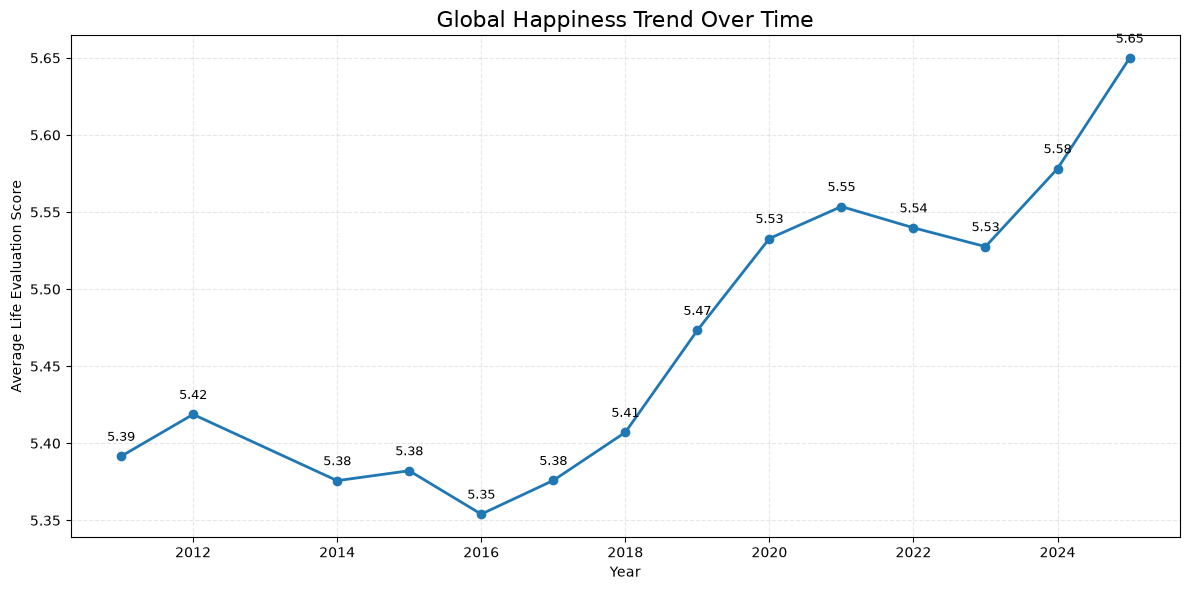

In [19]:
# Global happiness trend over time

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["Life evaluation (3-year average)"],
    marker="o",
    linewidth=2
)

# Add values to each point
for x, y in zip(
    yearly_happiness["Year"],
    yearly_happiness["Life evaluation (3-year average)"]
):
    plt.text(
        x,
        y + 0.01,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

plt.title(
    "Global Happiness Trend Over Time",
    fontsize=16
)

plt.xlabel("Year")
plt.ylabel("Average Life Evaluation Score")

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [20]:
# Year-over-year change in global happiness

yearly_change = yearly_happiness.copy()

yearly_change["Change"] = (
    yearly_change["Life evaluation (3-year average)"]
    .diff()
)

yearly_change["Change %"] = (
    yearly_change["Life evaluation (3-year average)"]
    .pct_change() * 100
)

print("Year-over-Year Happiness Change:")
display(
    yearly_change[
        ["Year", "Life evaluation (3-year average)", "Change", "Change %"]
    ].round(3)
)

Year-over-Year Happiness Change:


,Year,Life evaluation (3-year average),Change,Change %
0,2011,5.392,NaN,NaN
1,2012,5.419,0.027,0.504
2,2014,5.376,-0.043,-0.793
3,2015,5.382,0.006,0.120
4,2016,5.354,-0.028,-0.523
5,2017,5.376,0.022,0.408
6,2018,5.407,0.031,0.581
7,2019,5.473,0.066,1.223
8,2020,5.533,0.060,1.089
9,2021,5.554,0.021,0.375


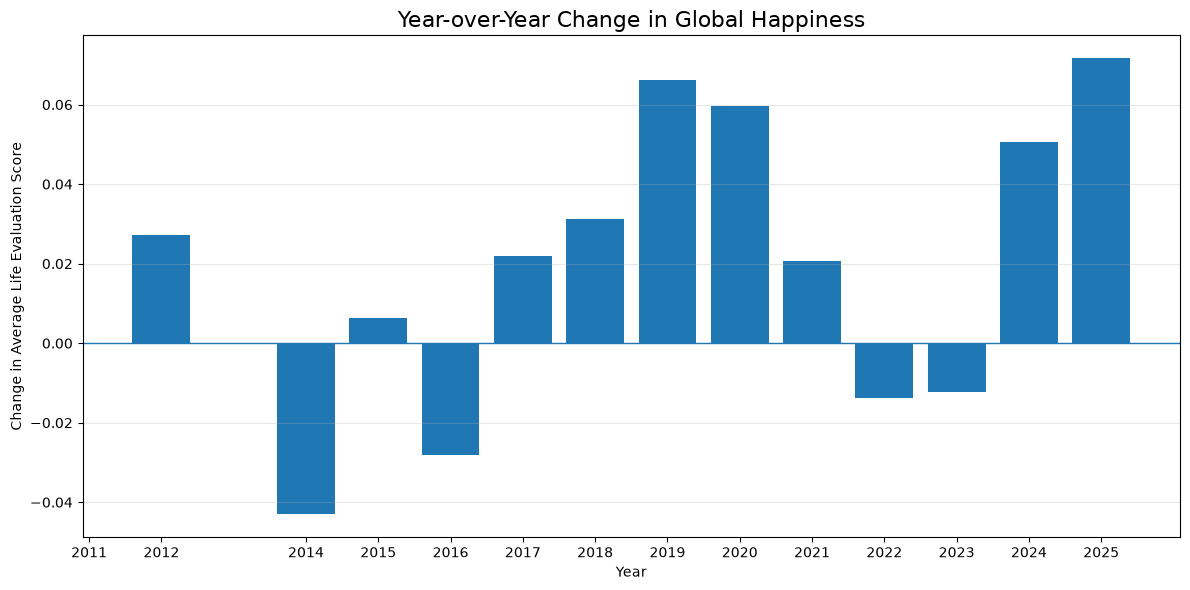

In [21]:
# Year-over-year happiness change

plt.figure(figsize=(12, 6))

plt.bar(
    yearly_change["Year"],
    yearly_change["Change"]
)

plt.axhline(0, linewidth=1)

plt.title("Year-over-Year Change in Global Happiness", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Change in Average Life Evaluation Score")

plt.xticks(yearly_change["Year"])


plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Correlation of each factor with happiness

happiness_corr = (
    correlation["Life evaluation (3-year average)"]
    .drop("Life evaluation (3-year average)")
    .sort_values(ascending=False)
)

print("Correlation of Happiness with Each Factor:")
display(happiness_corr.round(2))

Correlation of Happiness with Each Factor:


Explained by: Social support                  0.71
Explained by: Log GDP per capita              0.68
Explained by: Healthy life expectancy         0.66
Explained by: Freedom to make life choices    0.49
Explained by: Perceptions of corruption       0.43
Explained by: Generosity                      0.03
Name: Life evaluation (3-year average), dtype: float64

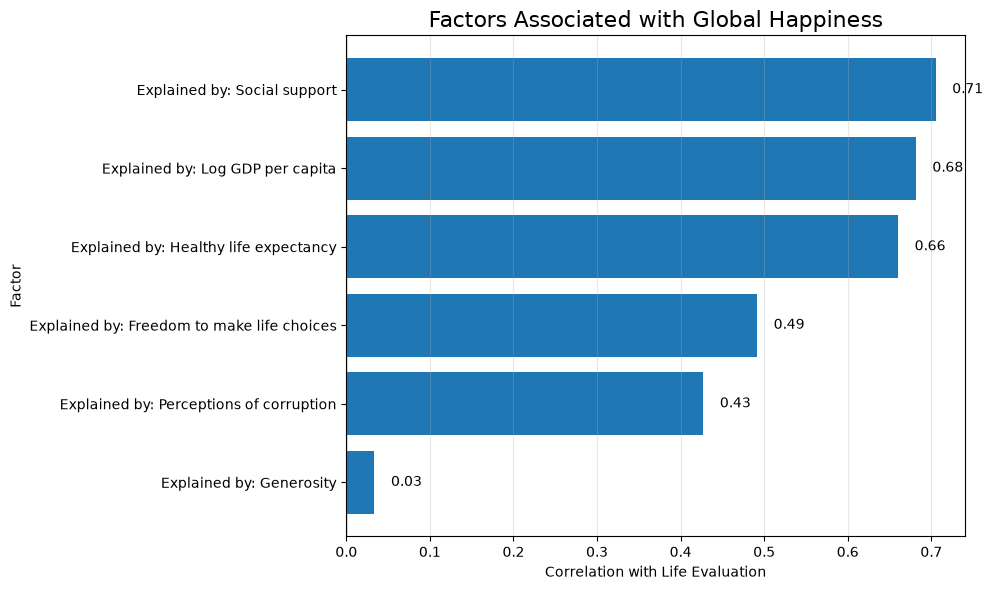

In [23]:
# Happiness factor correlation ranking

plt.figure(figsize=(10, 6))

bars = plt.barh(
    happiness_corr.index,
    happiness_corr.values
)

plt.axvline(0, linewidth=1)

plt.title(
    "Factors Associated with Global Happiness",
    fontsize=16
)

plt.xlabel("Correlation with Life Evaluation")
plt.ylabel("Factor")

plt.gca().invert_yaxis()

# Add values to bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + (0.02 if value >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

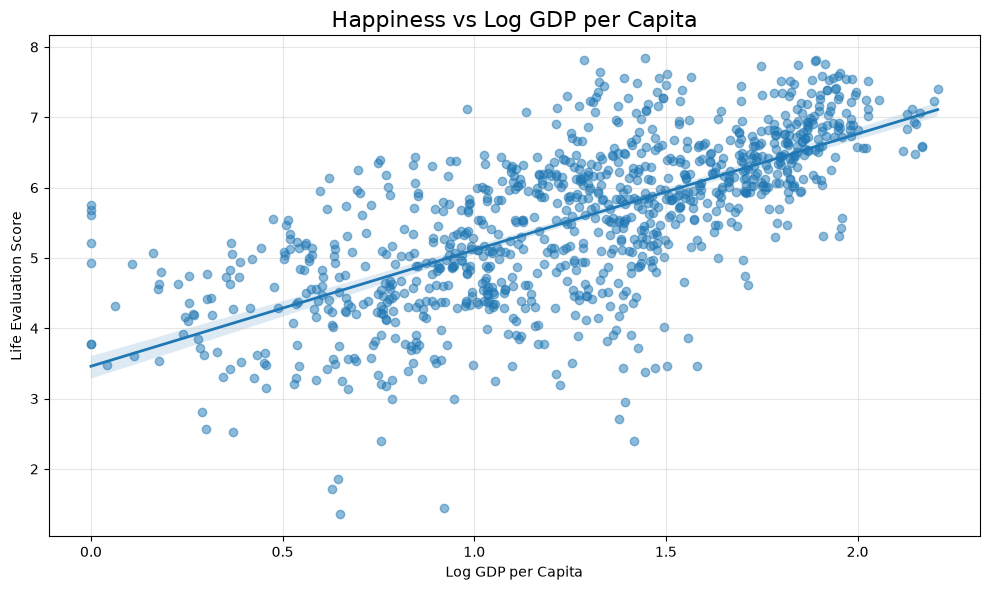

In [24]:
# Happiness vs GDP per capita

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_factors,
    x="Explained by: Log GDP per capita",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Happiness vs Log GDP per Capita", fontsize=16)
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation Score")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

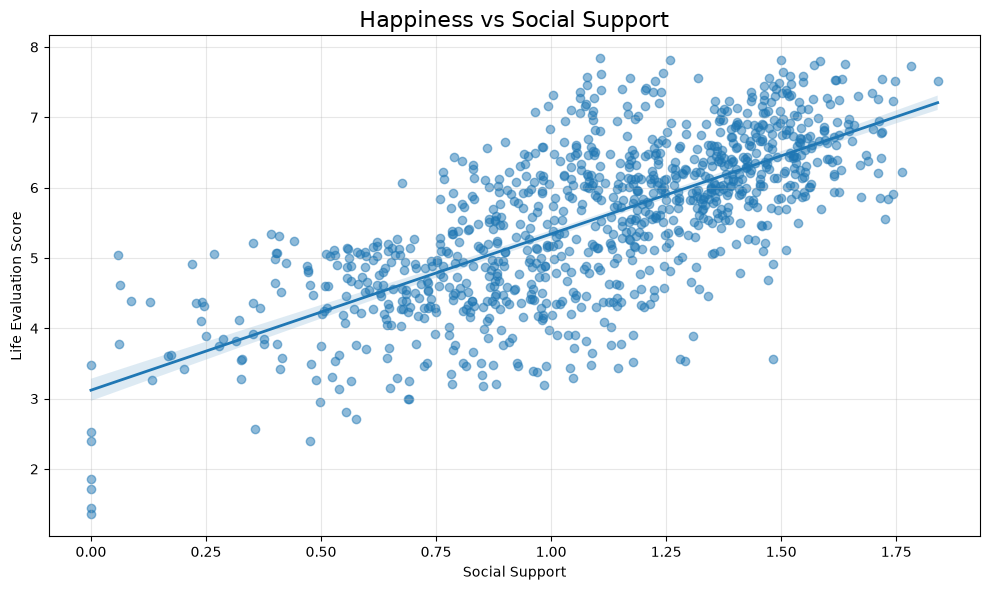

In [25]:
# Happiness vs Social Support

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_factors,
    x="Explained by: Social support",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Happiness vs Social Support", fontsize=16)
plt.xlabel("Social Support")
plt.ylabel("Life Evaluation Score")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

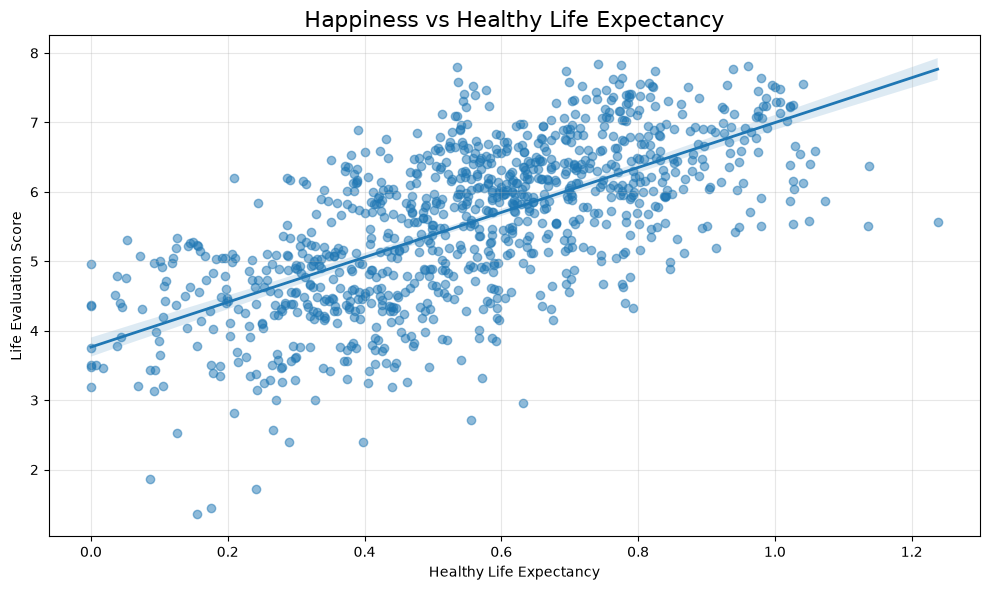

In [26]:
# Happiness vs Healthy Life Expectancy

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_factors,
    x="Explained by: Healthy life expectancy",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Happiness vs Healthy Life Expectancy", fontsize=16)
plt.xlabel("Healthy Life Expectancy")
plt.ylabel("Life Evaluation Score")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

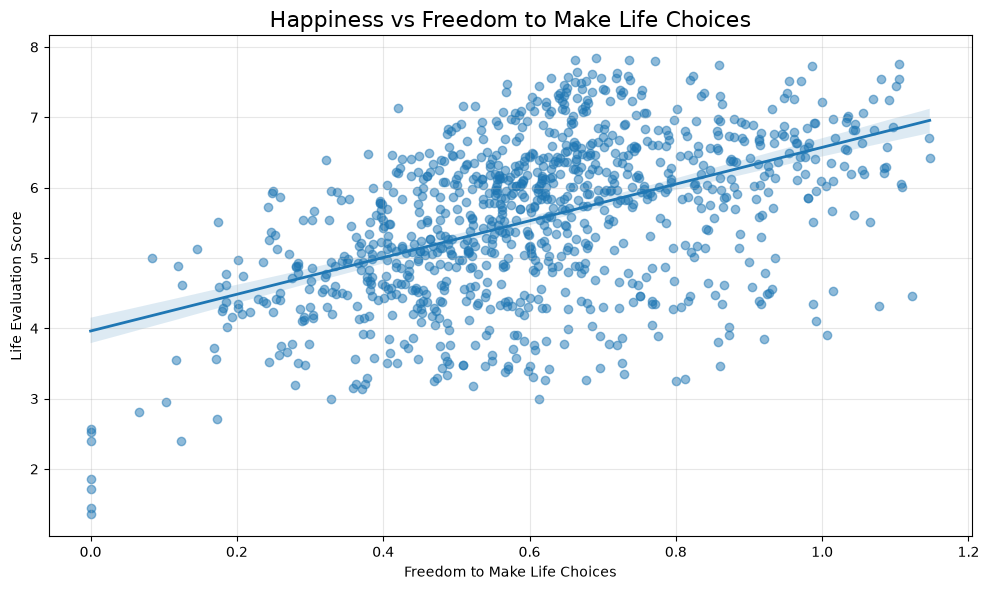

In [27]:
# Happiness vs Freedom to Make Life Choices

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_factors,
    x="Explained by: Freedom to make life choices",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Happiness vs Freedom to Make Life Choices", fontsize=16)
plt.xlabel("Freedom to Make Life Choices")
plt.ylabel("Life Evaluation Score")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# India-focused analysis

india_data = (
    df_clean[df_clean["Country name"] == "India"]
    .sort_values("Year")
)

print("India Happiness Data:")

display(
    india_data[
        [
            "Year",
            "Country name",
            "Life evaluation (3-year average)",
            "Explained by: Log GDP per capita",
            "Explained by: Social support",
            "Explained by: Healthy life expectancy",
            "Explained by: Freedom to make life choices",
            "Explained by: Generosity",
            "Explained by: Perceptions of corruption"
        ]
    ]
)

India Happiness Data:


,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
2053,2011,India,4.9750,NaN,NaN,NaN,NaN,NaN,NaN
1914,2012,India,4.7720,NaN,NaN,NaN,NaN,NaN,NaN
1762,2014,India,4.5650,NaN,NaN,NaN,NaN,NaN,NaN
1606,2015,India,4.4040,NaN,NaN,NaN,NaN,NaN,NaN
1455,2016,India,4.3150,NaN,NaN,NaN,NaN,NaN,NaN
1310,2017,India,4.1900,NaN,NaN,NaN,NaN,NaN,NaN
1161,2018,India,4.0150,NaN,NaN,NaN,NaN,NaN,NaN
1012,2019,India,3.5733,0.730576,0.644199,0.54057,0.581142,0.237072,0.105588
858,2020,India,3.8190,0.741000,0.316000,0.38300,0.622000,0.246000,0.106000
709,2021,India,3.7770,1.167000,0.376000,0.47100,0.647000,0.198000,0.123000


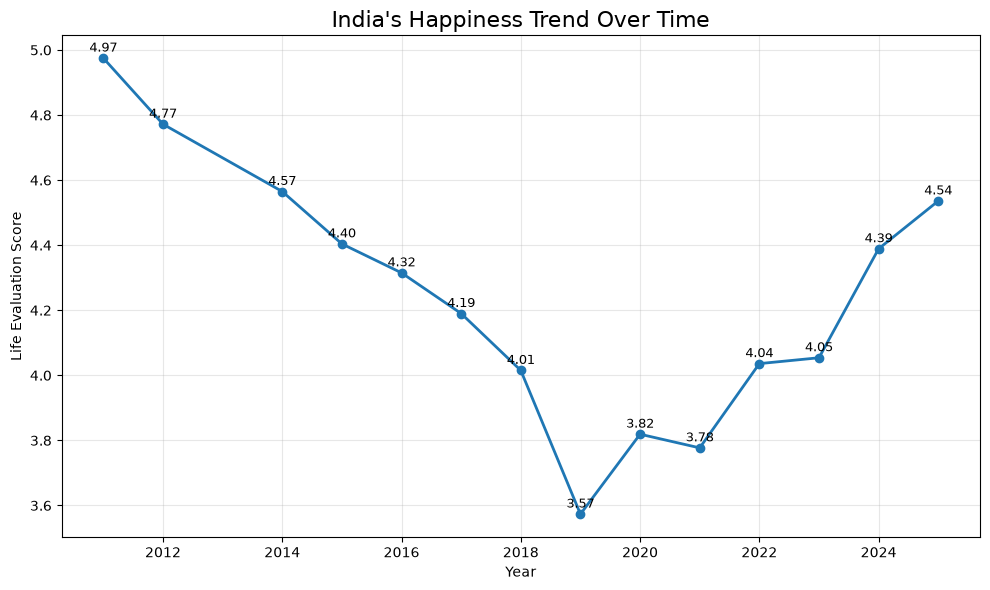

In [29]:
# India's happiness trend

plt.figure(figsize=(10, 6))

plt.plot(
    india_data["Year"],
    india_data["Life evaluation (3-year average)"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    india_data["Year"],
    india_data["Life evaluation (3-year average)"]
):
    plt.text(
        x,
        y + 0.02,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("India's Happiness Trend Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Life Evaluation Score")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

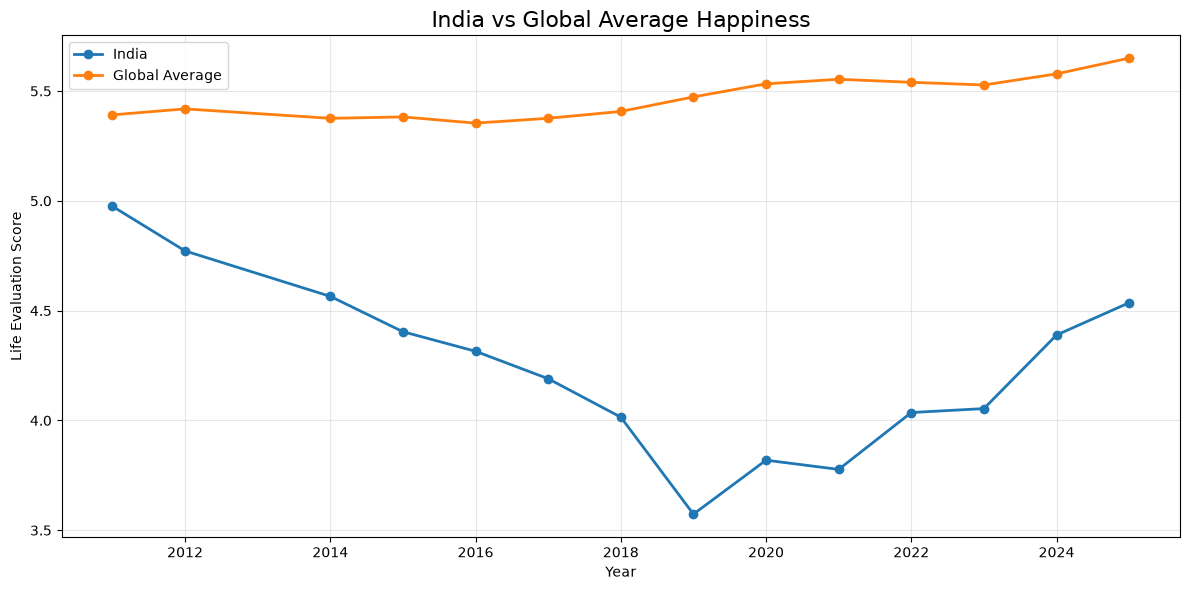

In [30]:
# India vs Global Average Happiness

global_yearly = (
    df_clean.groupby("Year")["Life evaluation (3-year average)"].mean().reset_index(name="Global Average")
)

india_compare = india_data[["Year", "Life evaluation (3-year average)"]].copy()

india_compare = india_compare.rename(
    columns={"Life evaluation (3-year average)": "India"}
)

comparison = pd.merge(
    india_compare,
    global_yearly,
    on="Year",
    how="inner"
)

plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Year"],
    comparison["India"],
    marker="o",
    linewidth=2,
    label="India"
)

plt.plot(
    comparison["Year"],
    comparison["Global Average"],
    marker="o",
    linewidth=2,
    label="Global Average"
)

plt.title("India vs Global Average Happiness", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Life Evaluation Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# India factor correlation analysis

india_factors = india_data[
    [
        "Life evaluation (3-year average)",
        "Explained by: Log GDP per capita",
        "Explained by: Social support",
        "Explained by: Healthy life expectancy",
        "Explained by: Freedom to make life choices",
        "Explained by: Generosity",
        "Explained by: Perceptions of corruption"
    ]
].copy()

# Calculate correlations
india_corr = (
    india_factors
    .corr()["Life evaluation (3-year average)"]
    .drop("Life evaluation (3-year average)")
    .sort_values(ascending=False)
)

print("India Happiness Factor Correlations:")
display(india_corr.round(2))

India Happiness Factor Correlations:


Explained by: Freedom to make life choices    0.97
Explained by: Log GDP per capita              0.79
Explained by: Social support                  0.65
Explained by: Perceptions of corruption       0.64
Explained by: Healthy life expectancy        -0.77
Explained by: Generosity                     -0.93
Name: Life evaluation (3-year average), dtype: float64

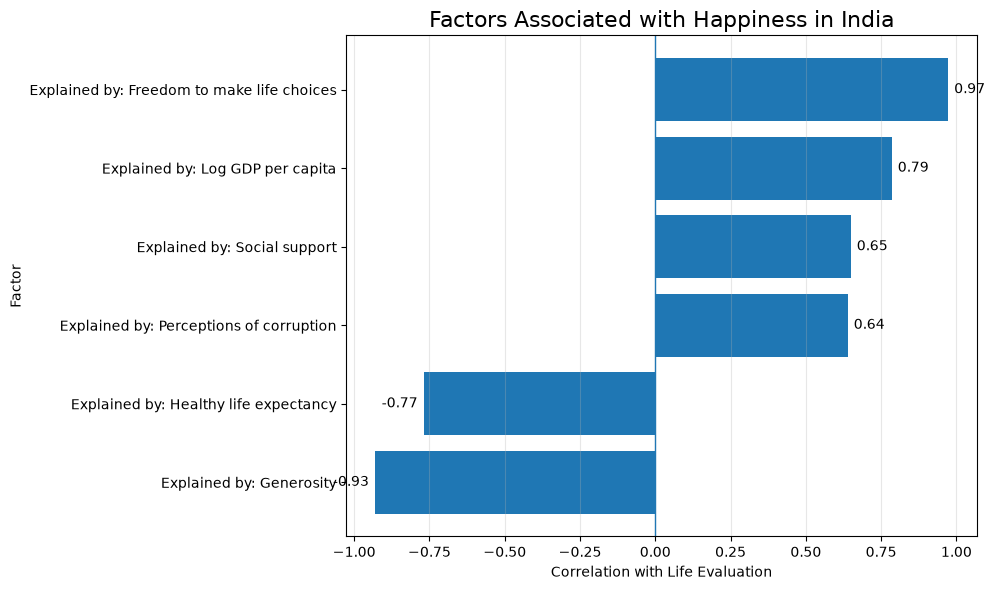

In [32]:
# India happiness factor correlation chart

plt.figure(figsize=(10, 6))

bars = plt.barh(
    india_corr.index,
    india_corr.values
)

plt.axvline(0, linewidth=1)

plt.title(
    "Factors Associated with Happiness in India",
    fontsize=16
)

plt.xlabel("Correlation with Life Evaluation")
plt.ylabel("Factor")

plt.gca().invert_yaxis()

for bar, value in zip(bars, india_corr.values):
    plt.text(
        value + (0.02 if value >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Check available India factor data

india_factors.info()

print("\nNon-missing values for each factor:")

display(
    india_factors.notna().sum().sort_values(ascending=False)
)

<class 'pandas.DataFrame'>
Index: 14 entries, 2053 to 115
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Life evaluation (3-year average)            14 non-null     float64
 1   Explained by: Log GDP per capita            7 non-null      float64
 2   Explained by: Social support                7 non-null      float64
 3   Explained by: Healthy life expectancy       7 non-null      float64
 4   Explained by: Freedom to make life choices  7 non-null      float64
 5   Explained by: Generosity                    7 non-null      float64
 6   Explained by: Perceptions of corruption     7 non-null      float64
dtypes: float64(7)
memory usage: 896.0 bytes

Non-missing values for each factor:


Life evaluation (3-year average)              14
Explained by: Log GDP per capita               7
Explained by: Social support                   7
Explained by: Healthy life expectancy          7
Explained by: Freedom to make life choices     7
Explained by: Generosity                       7
Explained by: Perceptions of corruption        7
dtype: int64

In [34]:
# Show the actual years used for factor analysis

india_factor_years = india_data[
    [
        "Year",
        "Life evaluation (3-year average)",
        "Explained by: Log GDP per capita",
        "Explained by: Social support",
        "Explained by: Healthy life expectancy",
        "Explained by: Freedom to make life choices",
        "Explained by: Generosity",
        "Explained by: Perceptions of corruption"
    ]
].dropna()

display(india_factor_years)

,Year,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
1012,2019,3.5733,0.730576,0.644199,0.54057,0.581142,0.237072,0.105588
858,2020,3.8190,0.741000,0.316000,0.38300,0.622000,0.246000,0.106000
709,2021,3.7770,1.167000,0.376000,0.47100,0.647000,0.198000,0.123000
562,2022,4.0360,1.159000,0.674000,0.25200,0.685000,0.175000,0.111000
419,2023,4.0540,1.166000,0.653000,0.41700,0.767000,0.174000,0.122000
264,2024,4.3890,1.149000,0.860000,0.31600,0.914000,0.141000,0.120000
115,2025,4.5360,1.397000,0.732000,0.29800,1.015000,0.121000,0.124000


In [35]:
# India: Factor changes from 2019 to 2025

india_2019_2025 = india_factor_years[
    india_factor_years["Year"].isin([2019, 2025])].set_index("Year")

factor_columns = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

india_factor_change = (
    india_2019_2025[factor_columns].T
)

india_factor_change["Change"] = (
    india_factor_change[2025] - india_factor_change[2019]
)

print("India Factor Changes: 2019 vs 2025")

display(india_factor_change.round(3))

India Factor Changes: 2019 vs 2025


Year,2019,2025,Change
Explained by: Log GDP per capita,0.731,1.397,0.666
Explained by: Social support,0.644,0.732,0.088
Explained by: Healthy life expectancy,0.541,0.298,-0.243
Explained by: Freedom to make life choices,0.581,1.015,0.434
Explained by: Generosity,0.237,0.121,-0.116
Explained by: Perceptions of corruption,0.106,0.124,0.018


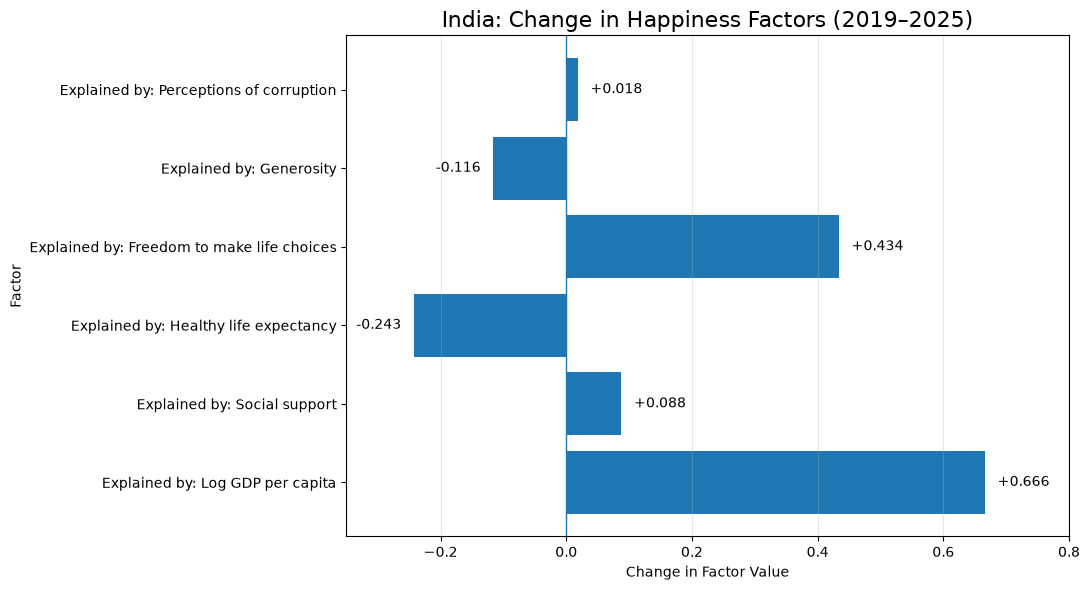

In [36]:
# India: Factor changes from 2019 to 2025

plt.figure(figsize=(11, 6))

bars = plt.barh(
    india_factor_change.index,
    india_factor_change["Change"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "India: Change in Happiness Factors (2019–2025)",
    fontsize=16
)

plt.xlabel("Change in Factor Value")
plt.ylabel("Factor")

# Add values to bars
for bar in bars:
    value = bar.get_width()

    if value >= 0:
        x_position = value + 0.02
        alignment = "left"
    else:
        x_position = value - 0.02
        alignment = "right"

    plt.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.3f}",
        va="center",
        ha=alignment,
        fontsize=10
    )

# Give labels enough space
plt.xlim(-0.35, 0.80)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Final Findings and Conclusion

## Global Findings

- Social support has the strongest positive correlation with happiness (0.71).
- Log GDP per capita has a strong positive correlation (0.68).
- Healthy life expectancy also has a strong positive correlation (0.66).
- Freedom and generosity show moderate positive relationships with happiness.
- Perceptions of corruption have very weak linear correlation in the global dataset.

## India Findings

- India's happiness declined from about 4.98 in 2011 to about 3.57 in 2019.
- India's happiness recovered after 2019 and reached about 4.54 in 2025.
- India remained below the global average during the analyzed period.
- From 2019 to 2025, Log GDP per capita increased by 0.666.
- Freedom to make life choices increased by 0.434.
- Social support increased by 0.088.
- Healthy life expectancy decreased by 0.243.
- Generosity decreased by 0.116.

## Conclusion

Overall, the analysis shows that happiness is associated with economic, social, health, and personal factors.

For India, happiness improved after 2019, while economic conditions and freedom-related measures increased substantially. However, healthy life expectancy and generosity decreased.

These results show associations in the dataset and do not prove that one factor directly causes happiness.

In [37]:
# Country ranking analysis - latest available year

latest_year = df_clean["Year"].max()

latest_data = (
    df_clean[df_clean["Year"] == latest_year].sort_values("Life evaluation (3-year average)", ascending=False)
)

print(f"Country Happiness Ranking - {latest_year}")

display(
    latest_data[
        [
            "Rank",
            "Country name",
            "Life evaluation (3-year average)"
        ]].head(10).reset_index(drop=True)
)

Country Happiness Ranking - 2025


,Rank,Country name,Life evaluation (3-year average)
0,1,Finland,7.764
1,2,Iceland,7.540
2,3,Denmark,7.539
3,4,Costa Rica,7.439
4,5,Sweden,7.255
5,6,Norway,7.242
6,7,Netherlands,7.223
7,8,Israel,7.187
8,9,Luxembourg,7.063
9,10,Switzerland,7.018


In [ ]:
# Bottom 10 happiest countries

print(f"Lowest Happiness Scores - {latest_year}")

display(
    latest_data[
        [
            "Rank",
            "Country name",
            "Life evaluation (3-year average)"
        ]].tail(10).sort_values("Life evaluation (3-year average)").reset_index(drop=True)
)

Lowest Happiness Scores - 2025


,Rank,Country name,Life evaluation (3-year average)
0,147,Afghanistan,1.446
1,146,Sierra Leone,3.251
2,145,Malawi,3.284
3,144,Zimbabwe,3.346
4,143,Botswana,3.464
5,142,Yemen,3.532
6,141,Lebanon,3.723
7,140,DR Congo,3.761
8,139,Egypt,3.862
9,138,Tanzania,3.902


- Finland had the highest life evaluation score in 2025, at approximately 7.76.
- Afghanistan had the lowest life evaluation score in 2025, at approximately 1.45.